In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

In [2]:

!pip install kagglehub -q

import kagglehub
import os


dataset_path = kagglehub.dataset_download("msambare/fer2013")


train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")


print("Train directory:", train_dir)
print("Test directory:", test_dir)

Using Colab cache for faster access to the 'fer2013' dataset.
Train directory: /kaggle/input/fer2013/train
Test directory: /kaggle/input/fer2013/test


In [3]:
os.listdir(train_dir)

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']

### Count images in each class

In [4]:
class_counts = {}

for emotion in os.listdir(train_dir):

    emotion_path = os.path.join(train_dir, emotion)

    if os.path.isdir(emotion_path):
        class_counts[emotion] = len(os.listdir(emotion_path))

class_counts

{'surprise': 3171,
 'fear': 4097,
 'angry': 3995,
 'neutral': 4965,
 'sad': 4830,
 'disgust': 436,
 'happy': 7215}

### Plot class distribution

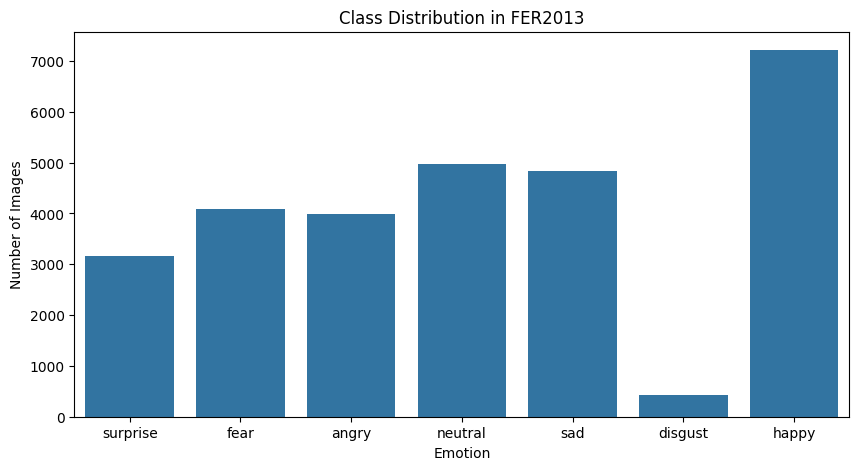

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution in FER2013")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.show()

### Display sample images

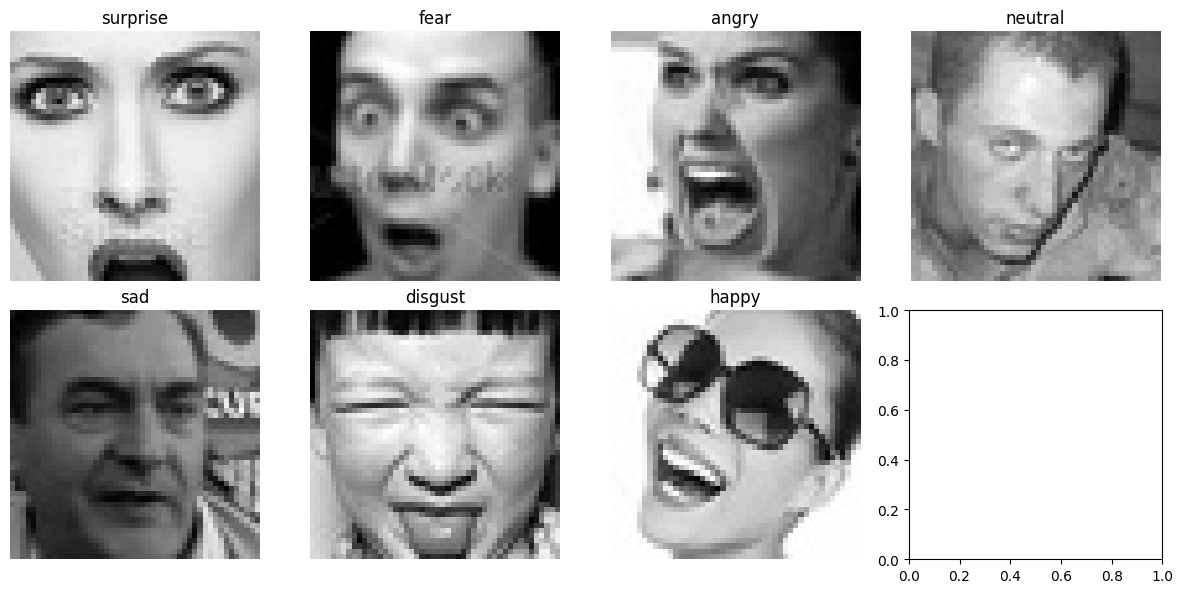

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

axes = axes.flatten()

for idx, emotion in enumerate(os.listdir(train_dir)[:7]):

    emotion_path = os.path.join(train_dir, emotion)

    image_name = random.choice(os.listdir(emotion_path))

    image_path = os.path.join(emotion_path, image_name)

    image = Image.open(image_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(emotion)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Check image shape

In [7]:
sample_emotion = random.choice(os.listdir(train_dir))

sample_path = os.path.join(
    train_dir,
    sample_emotion,
    random.choice(os.listdir(os.path.join(train_dir, sample_emotion)))
)

image = Image.open(sample_path)

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (48, 48)


In [8]:
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Minimum pixel value: 0
Maximum pixel value: 233


### Display sample grayscale image

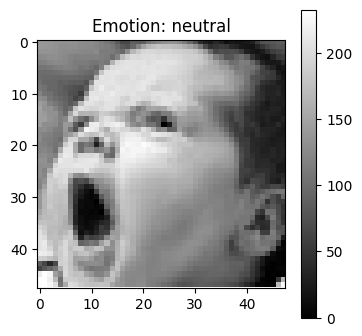

In [9]:
plt.figure(figsize=(4,4))

plt.imshow(image_array, cmap="gray")

plt.title(f"Emotion: {sample_emotion}")

plt.colorbar()

plt.show()

# EDA Observations

## Dataset Findings

- FER2013 contains grayscale facial images of size 48×48.
- The dataset is imbalanced, especially for the disgust class.
- Several images are blurry, noisy, and low contrast.
- Some emotions visually overlap, especially fear and surprise.
- Small image resolution makes emotion recognition difficult.
- Data augmentation and regularization will likely be important.

In [10]:
import torch
import os

train_path = train_dir
emotions = os.listdir(train_path)

print(f"Total emotions categories found: {len(emotions)}")
print(f"Emotion classes: {emotions}")

Total emotions categories found: 7
Emotion classes: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


### Create data transforms and loaders

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])


### Load datasets and batches

In [12]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Total training batches: {len(train_loader)}")

Total training batches: 449


### Apply custom augmentations

In [13]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

mild_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])


heavy_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.8),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])


test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])


class TargetedFERDataset(Dataset):
    def __init__(self, root_dir, is_train=True):
        self.root_dir = root_dir
        self.is_train = is_train
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.image_paths = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    self.image_paths.append(os.path.join(cls_dir, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('L')

        if self.is_train:
            if self.classes[label] == 'disgust':
                image = heavy_transforms(image)
            else:
                image = mild_transforms(image)
        else:
            image = test_transforms(image)

        return image, label

train_dataset = TargetedFERDataset(root_dir=train_dir, is_train=True)
test_dataset = TargetedFERDataset(root_dir=test_dir, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Targeted Pipeline Ready! Total training batches: {len(train_loader)}")

Targeted Pipeline Ready! Total training batches: 449


### Check batch shapes

In [14]:
imgs, lbls = next(iter(train_loader))

print(imgs.shape)
print(lbls.shape)

torch.Size([64, 1, 48, 48])
torch.Size([64])


### Build custom CNN model

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += self.shortcut(x)
        out = F.relu(out)
        return out

class CustomFERModel(nn.Module):
    def __init__(self):
        super(CustomFERModel, self).__init__()

        self.prep = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.layer1 = ResBlock(32, 64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.layer2 = ResBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.layer3 = ResBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.pool1(x)
        x = self.layer2(x)
        x = self.pool2(x)
        x = self.layer3(x)
        x = self.pool3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

m = CustomFERModel()
print("Custom Hybrid Model (ResNet + GAP) Ready!")
print(m)

Custom Hybrid Model (ResNet + GAP) Ready!
CustomFERModel(
  (prep): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (layer2): ResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

### Setup training configuration

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m = CustomFERModel().to(device)

counts = [3995, 436, 4097, 7215, 4965, 4830, 3171]
w = [1.0/c for c in counts]
w_t = torch.tensor(w, dtype=torch.float).to(device)

crit = nn.CrossEntropyLoss(weight=w_t)
opt = optim.Adam(m.parameters(), lr=0.001)


sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

eps = 30

print(f"Training on {device} ")

for ep in range(eps):
    m.train()
    tot_loss = 0.0
    corr = 0
    tot = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()

        out = m(x)
        loss = crit(out, y)

        loss.backward()
        opt.step()

        tot_loss += loss.item()
        _, preds = torch.max(out, 1)
        corr += (preds == y).sum().item()
        tot += y.size(0)

    acc = 100 * corr / tot
    avg_loss = tot_loss / len(train_loader)


    sch.step(avg_loss)

    print(f"Ep {ep+1}/{eps} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")


torch.save(m.state_dict(), 'custom_fer_model.pth')


Training on cuda 
Ep 1/30 | Loss: 1.8578 | Acc: 20.28%
Ep 2/30 | Loss: 1.6125 | Acc: 31.41%
Ep 3/30 | Loss: 1.4472 | Acc: 41.79%
Ep 4/30 | Loss: 1.3335 | Acc: 47.15%
Ep 5/30 | Loss: 1.2460 | Acc: 51.18%
Ep 6/30 | Loss: 1.1838 | Acc: 53.56%
Ep 7/30 | Loss: 1.1505 | Acc: 54.69%
Ep 8/30 | Loss: 1.1197 | Acc: 56.49%
Ep 9/30 | Loss: 1.0774 | Acc: 57.81%
Ep 10/30 | Loss: 1.0513 | Acc: 58.64%
Ep 11/30 | Loss: 1.0415 | Acc: 59.25%
Ep 12/30 | Loss: 1.0172 | Acc: 60.29%
Ep 13/30 | Loss: 0.9931 | Acc: 61.00%
Ep 14/30 | Loss: 0.9540 | Acc: 62.22%
Ep 15/30 | Loss: 0.9683 | Acc: 62.04%
Ep 16/30 | Loss: 0.9368 | Acc: 63.30%
Ep 17/30 | Loss: 0.9083 | Acc: 63.94%
Ep 18/30 | Loss: 0.9132 | Acc: 64.37%
Ep 19/30 | Loss: 0.9006 | Acc: 64.61%
Ep 20/30 | Loss: 0.8763 | Acc: 65.05%
Ep 21/30 | Loss: 0.8676 | Acc: 65.59%
Ep 22/30 | Loss: 0.8498 | Acc: 66.50%
Ep 23/30 | Loss: 0.8360 | Acc: 67.04%
Ep 24/30 | Loss: 0.8293 | Acc: 67.26%
Ep 25/30 | Loss: 0.8145 | Acc: 67.85%
Ep 26/30 | Loss: 0.7903 | Acc: 68.39%
Ep 

### Evaluate model performance


FINAL TEST ACCURACY: 62.71% 



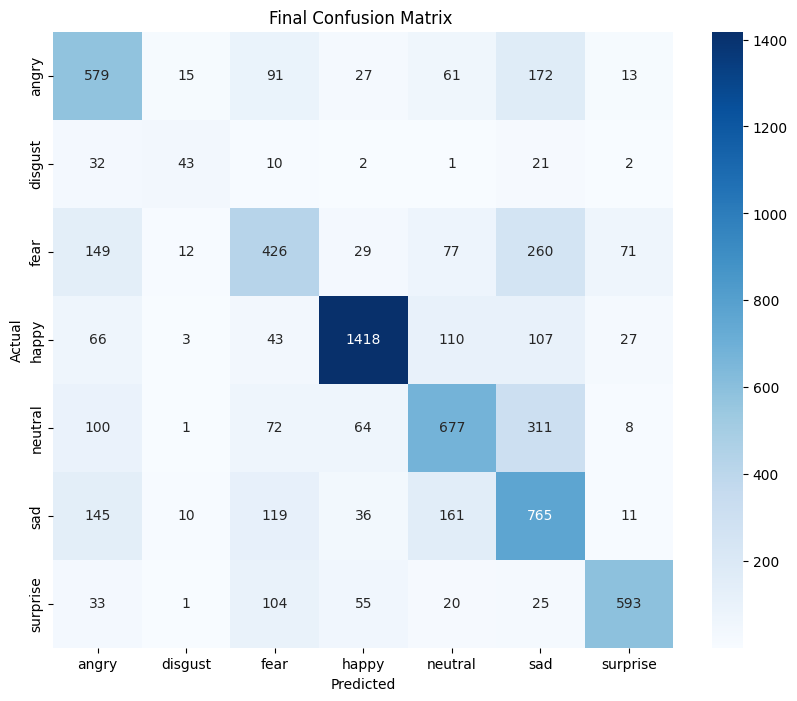

--- Final Detailed Report Card ---
              precision    recall  f1-score   support

       angry       0.52      0.60      0.56       958
     disgust       0.51      0.39      0.44       111
        fear       0.49      0.42      0.45      1024
       happy       0.87      0.80      0.83      1774
     neutral       0.61      0.55      0.58      1233
         sad       0.46      0.61      0.53      1247
    surprise       0.82      0.71      0.76       831

    accuracy                           0.63      7178
   macro avg       0.61      0.58      0.59      7178
weighted avg       0.64      0.63      0.63      7178



In [17]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

m.eval()

all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:

        x, y = x.to(device), y.to(device)

        out = m(x)
        _, preds = torch.max(out, 1)

        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = 100 * correct / total
print(f"\nFINAL TEST ACCURACY: {test_acc:.2f}% \n")

classes = test_dataset.classes
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix ')
plt.savefig('final_confusion_matrix.png')
plt.show()

print("--- Final Detailed Report Card ---")
print(classification_report(all_labels, all_preds, target_names=classes))

### Test model prediction

In [18]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms

m_test = CustomFERModel()
m_test.load_state_dict(torch.load('custom_fer_model.pth', map_location=torch.device('cpu')))
m_test.eval()

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict_emotion(img_path):
    img = Image.open(img_path)
    img_t = test_transforms(img).unsqueeze(0)

    with torch.no_grad():
        out = m_test(img_t)
        _, pred = torch.max(out, 1)

    classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
    return classes[pred.item()]

